# <center> <font color="#0036a3">Maestría en Inteligencia Artificial Aplicada (MNA)</font> </center>

<center>

[![Institución](https://img.shields.io/badge/INSTITUCIÓN-TECNOLÓGICO_DE_MONTERREY-0036a3?style=for-the-badge)](https://tec.mx)
[![Programa](https://img.shields.io/badge/PROGRAMA-MNA-0036a3?style=for-the-badge)](https://tec.mx)
[![Materia](https://img.shields.io/badge/MATERIA-PROYECTO_INTEGRADOR-E0A800?style=for-the-badge&logoColor=white)](https://tec.mx)

</center>

<center>

[![Python](https://img.shields.io/badge/Python-3776AB?style=flat-square&logo=python&logoColor=white)](https://www.python.org/)
[![Jupyter](https://img.shields.io/badge/Jupyter-F37626?style=flat-square&logo=jupyter&logoColor=white)](https://jupyter.org/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat-square&logo=numpy&logoColor=white)](https://numpy.org/)
[![OpenCV](https://img.shields.io/badge/OpenCV-5C3EE8?style=flat-square&logo=opencv&logoColor=white)](https://opencv.org/)
[![GitHub](https://img.shields.io/badge/Repo-GitHub-181717?style=flat-square&logo=github&logoColor=white)](https://github.com/jmtoral/proyecto_integrador_52)

</center>

---

## **<font color="#0036a3">Semana 3: Avance 1 — Análisis Exploratorio de Datos (EDA)</font>**

### **<font color="#E0A800">Proyecto Integrador — TC5035.10</font>**
**Materia:** Proyecto Integrador — TC5035.10

> **Título:** La luz que opaca: Detección y supresión de reflejos especulares en imágenes endoscópicas.

---

### **Equipo Docente**
* **Dra. Grettel Barceló Alonso** | Profesora Titular
* **Dr. Luis Eduardo Falcón Morales** | Profesor Titular
* **Mtra. Verónica Sandra Guzmán de Valle** | Profesora Asistente

**Patrocinador:** Dr. Gerardo Camacho

---

## **<center> <font color="#0036a3">Equipo 52</font> </center>**

<table style="width:100%; border:none; border-collapse:collapse;">
  <tr>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/elda.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>Elda Cristina Morales Sánchez de la Barquera</h4>
      <code>A00449074</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/mpgc.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>María Paula Gutiérrez Cervantes</h4>
      <code>A01747706</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/jmtc.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>José Manuel Toral Cruz</h4>
      <code>A01122243</code><br>
      <small>MNA Student</small>
    </td>
  </tr>
</table>

---

### **<font color="#E0A800">Información de Entrega</font>**
* **Actividad:** Avance 1. Análisis exploratorio de datos.
* **Fecha Límite:** 11 de mayo de 2026
* **Framework de Calidad:** CRISP-ML(Q)
* **Objetivos Clave:**
    * **Exploración del dataset:** Caracterización estructural del dataset C3VDv2 . Definición de la volumetría final de análisis, validar los tipos de datos, analizar los rangos de parámetros de captura (como velocidad de cámara y brillo) , y examinar la distribución de escenarios desafiantes mediante la frecuencia de sus etiquetas (ej. presencia de escombros, agua en el lente, o movimiento rápido).
    * **Ground Truth:** Análisis de la calidad de la alineación entre las imágenes y los modelos 3D evaluando la distribución de los puntajes cualitativos y cuantitativos (Dice score y distancia Chamfer) . Se documentará específicamente la restricción arquitectónica del dataset donde los mapas de profundidad y oclusión para los videos con escombros (v3) se heredan directamente de sus pares limpios (v2).

---

## EDA 00 — Exploración del dataset C3VDv2

**¿Qué estudia este notebook?**

Este notebook se centra exclusivamente en la caracterización y auditoría del dataset C3VDv2 (Colonoscopy 3D Video Dataset v2). El análisis busca entender la estructura, calidad y límites de los datos, resolviendo las siguientes preguntas clave:

1. ¿Cómo varían las condiciones técnicas de captura entre las distintas regiones anatómicas?
2. ¿Cuál es la volumetría real del dataset apta para tareas con ground truth a nivel de píxel?
3. ¿Qué tan confiable es la alineación entre los fotogramas de video y el modelo 3D?

---

### Estructura

1.   Integridad, esquema y valores faltantes (o ausencia de datos)
2.   Análisis univariado de metadatos
3.   Análisis bivariado y multivariado de metadatos
4.   Análisis temporal (intra-video)
5.   Análisis a nivel de imagen y profundidad (Pixel-Level EDA)
6.   Sesgo Espacial y Balance de Clases
7.   Síntesis y reporte del EDA

## Etapa 1: Integridad, esquema y valores faltantes (o ausencia de datos)
Este bloque se encarga de aislar los 169 videos con ground truth, estandarizar las inconsistencias de texto como los dobles espacios o errores tipográficos, y generar el mapa de calor para lograr visualizar exactamente dónde están los valores nulos.

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# ETAPA 1: Integridad, esquema y valores faltantes
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Cargar metadatos
metadatos = '/content/drive/MyDrive/Colab Notebooks/EDA_C3VD/C3VDv2_Data_Summary_Sheet_v1.xlsx'
df = pd.read_excel(metadatos)
df.columns = df.columns.str.strip()  # quita el trailing space en 'Video Number '
print(f"Total de videos antes del filtro: {len(df)}")

# 2. Higiene de Datos — normalización robusta de TODAS las columnas string
def norm_str(s):
    """strip + lower + colapsa whitespace interno"""
    return s.fillna('').astype(str).str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)

for col in ['Open End Visible', 'Debris', 'Deformation', 'Tags', 'Segment']:
    df[col] = norm_str(df[col])

# Corrección tipográfica conocida en Tags
df['Tags'] = df['Tags'].str.replace('zizag', 'zigzag', regex=False)

# Renombrar segmentos sigmoides para preservar herencia anatómica
# (c1 tiene sigmoid1+sigmoid2; c2 tiene un único sigmoid — NO son lo mismo)
df['Segment Full'] = df['Colon'] + '_' + df['Segment']

print("Higiene completada: strings normalizados, tags corregidos, segmentos desambiguados.")

# 3. Clasificación de tipo de video (v1/v2/v3/v4/full)
df['vtype'] = df['Video Name'].str.extract(r'_(v\d|full)$', expand=False)
print("\nDistribución por tipo de video:")
print(df['vtype'].value_counts())

# 4. Validación de Missingness Estructural — extendida a TODAS las columnas
print("\n--- DIAGNÓSTICO DE INTEGRIDAD ---")

# Patrones estructurales esperados:
#   v3      → Quantitative Score == NaN  (registro heredado de v2)
#   v4/full → Qualitative Score  == NaN  (sin pixel GT)
#   full    → Camera Speed, Brightness, Deformation == NaN  (captura manual sin UR3e)
is_v3       = df['vtype'] == 'v3'
is_v4_full  = df['vtype'].isin(['v4', 'full'])
is_full     = df['Segment'] == 'full'

checks = {
    'v3 → Quantitative Score NaN'         : df.loc[is_v3, 'Quantitative Score'].isnull().all(),
    'v4/full → Qualitative Score NaN'     : df.loc[is_v4_full, 'Qualitative Score'].isnull().all(),
    'full → Camera Speed NaN'             : df.loc[is_full, 'Camera Speed'].isnull().all(),
    'full → Brightness NaN'               : df.loc[is_full, 'Brightness'].isnull().all(),
    'full → Deformation NaN'              : df.loc[is_full, 'Deformation'].isnull().all() or (df.loc[is_full,'Deformation']=='nan').all(),
}
for descr, ok in checks.items():
    print(f"  [{'OK' if ok else 'FALLA'}]  {descr}")

# 5. Detección de anomalías = nulos fuera de los patrones estructurales
def anomalias_columna(col, estructural_mask):
    """Cuenta nulos que NO están justificados por el patrón estructural."""
    return df.loc[~estructural_mask, col].isnull().sum()

anomalias = {
    'Quantitative Score' : anomalias_columna('Quantitative Score', is_v3 | is_v4_full),
    'Qualitative Score'  : anomalias_columna('Qualitative Score', is_v4_full),
    'Camera Speed'       : anomalias_columna('Camera Speed', is_full),
    'Brightness'         : anomalias_columna('Brightness', is_full),
}
print("\nAnomalías de missingness (nulos fuera del patrón):")
for col, n in anomalias.items():
    print(f"  {col:25s}  {n}")

# 6. Integridad referencial: pareo v2/v3
v2_bases = set(df.loc[df.vtype=='v2', 'Video Name'].str.replace('_v2', '', regex=False))
v3_bases = set(df.loc[df.vtype=='v3', 'Video Name'].str.replace('_v3', '', regex=False))
print(f"\nPareo v2/v3:")
print(f"  Pares completos: {len(v2_bases & v3_bases)}")
print(f"  v2 sin v3:       {sorted(v2_bases - v3_bases)}")
print(f"  v3 sin v2:       {sorted(v3_bases - v2_bases)}")

# 7. Mapa de calor de nulos — excluyendo Comments (siempre disperso, ensucia la visualización)
cols_heatmap = [c for c in df.columns if c not in ['Comments', 'Youtube Preview URL ID', 'vtype', 'Segment Full']]
plt.figure(figsize=(12, 5))
sns.heatmap(df[cols_heatmap].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Etapa 1 — Mapa de Calor de Valores Faltantes (Comments excluida)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 8. Cardinalidad de variables categóricas (responde Q4 del pipeline)
print("\n--- CARDINALIDAD DE VARIABLES CATEGÓRICAS ---")
cat_cols = ['Colon', 'Segment', 'Segment Full', 'Phantom Number', 'Video Number',
            'Debris', 'Deformation', 'Open End Visible', 'vtype', 'Qualitative Score']
card = pd.DataFrame({
    'columna'   : cat_cols,
    'únicos'    : [df[c].nunique(dropna=True) for c in cat_cols],
    'valores'   : [sorted(map(str, df[c].dropna().unique()))[:8] for c in cat_cols],
})
print(card.to_string(index=False))

# 9. Filtrado para análisis técnico (v1, v2, v3 — únicos con per-pixel GT)
df_filtered = df[df['vtype'].isin(['v1', 'v2', 'v3'])].copy()
print(f"\n--- Resumen Etapa 1 ---")
print(f"Videos originales: {len(df)}")
print(f"Videos con per-pixel GT (v1+v2+v3): {len(df_filtered)}")
print(f"Excluidos (v4 deformación + full screening): {len(df) - len(df_filtered)}")

## Etapa 2: Análisis univariado de metadatos
En esta etapa examinamos la distribución individual de cada variable presente en los metadatos. El objetivo principal es identificar el comportamiento estadístico de los parámetros técnicos (velocidad, brillo, cuadros totales) y la frecuencia de los escenarios clínicos.

Distribución Numérica: Identificamos sesgos (skewness) que podrían requerir transformaciones logarítmicas.

Detección de Outliers: Localizamos videos con duraciones o velocidades extremas que podrían introducir ruido en el entrenamiento.

Balance Categórico: Evaluamos la representatividad de cada segmento anatómico y etiqueta clínica para entender el alcance del dataset.


In [ ]:
# ==========================================
# ETAPA 2: Análisis univariado de metadatos
# ==========================================

# 1. Transformación candidata: log para columnas con sesgo
df_filtered['Total Frames Log']  = np.log1p(df_filtered['Total Frames'])
df_filtered['Camera Speed Log']  = np.log1p(df_filtered['Camera Speed'])

# 2. Tabla de skewness y kurtosis — responde Q5 cuantitativamente
print("--- COEFICIENTES DE SESGO Y CURTOSIS ---")
cols_num = ['Camera Speed', 'Camera Speed Log', 'Brightness', 'Edge Enhancement',
            'Quantitative Score', 'Total Frames', 'Total Frames Log']
skew_table = pd.DataFrame({
    'n'        : [df_filtered[c].dropna().shape[0] for c in cols_num],
    'media'    : [df_filtered[c].mean()  for c in cols_num],
    'std'      : [df_filtered[c].std()   for c in cols_num],
    'skewness' : [df_filtered[c].skew()  for c in cols_num],
    'kurtosis' : [df_filtered[c].kurt()  for c in cols_num],
}, index=cols_num).round(2)

# Recomendación automática de transformación
def recomendar(skew):
    if abs(skew) < 0.5:   return 'ninguna'
    if abs(skew) < 1.0:   return 'opcional'
    return 'requerida (log)'
skew_table['transformación'] = skew_table['skewness'].apply(recomendar)
print(skew_table.to_string())
print("\nHallazgo clave: Camera Speed es la única variable con sesgo fuerte (+2.07).")
print("La transformación log la reduce de manera dramática (ver tabla).")

# 3. Histograma + boxplot para variables numéricas (en su forma original)
cols_plot = ['Camera Speed', 'Brightness', 'Edge Enhancement',
             'Quantitative Score', 'Total Frames']
for col in cols_plot:
    if col not in df_filtered.columns: continue
    fig, ax = plt.subplots(1, 2, figsize=(12, 3))
    s = df_filtered[col].dropna()
    sns.histplot(s, kde=True, ax=ax[0], color='teal')
    ax[0].set_title(f'Distribución: {col}  (skew={s.skew():+.2f})')
    sns.boxplot(x=s, ax=ax[1], color='lightcoral')
    ax[1].set_title(f'Outliers: {col}')
    plt.tight_layout()
    plt.show()

# 4. Categóricas — Segment FACETADO por Colon (corrige la falsa equivalencia c1/c2)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, colon in zip(axes, ['c1', 'c2']):
    sub = df_filtered[df_filtered['Colon'] == colon]
    orden = sub['Segment'].value_counts().index
    sns.countplot(data=sub, x='Segment', order=orden, ax=ax,
                  hue='Segment', palette='viridis', legend=False)
    ax.set_title(f'Frecuencia de segmentos: Colon {colon}  (n={len(sub)})')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print("Nota: Colon 1 tiene sigmoid1/sigmoid2; Colon 2 tiene un único sigmoid.")
print("Son segmentos anatómicos DISTINTOS, no se deben agregar.")

# 5. Otras categóricas
cols_cat = ['Debris', 'Open End Visible', 'Qualitative Score', 'vtype']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, cols_cat):
    orden = df_filtered[col].value_counts(dropna=False).index
    sns.countplot(data=df_filtered, x=col, order=orden, ax=ax,
                  hue=col, palette='viridis', legend=False)
    ax.set_title(f'Frecuencia: {col}')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# 6. Tags — tokenización + frecuencia
tags_long = (df_filtered.assign(tag=df_filtered['Tags'].str.split(';'))
                        .explode('tag')
                        .assign(tag=lambda d: d['tag'].str.strip())
                        .query("tag != ''"))
tag_counts = tags_long['tag'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=tag_counts.values, y=tag_counts.index, ax=axes[0],
            hue=tag_counts.index, palette='magma', legend=False)
axes[0].set_title(f'Frecuencia de tags (n_videos={len(df_filtered)})')
axes[0].set_xlabel('Conteo de videos con el tag')

# Distribución del número de tags por video
tags_per_video = (df_filtered['Tags'].str.split(';')
                                     .apply(lambda L: sum(1 for t in L if t.strip()))
                                     .rename('n_tags'))
sns.histplot(tags_per_video, discrete=True, ax=axes[1], color='darkorange')
axes[1].set_title(f'Tags por video  (media={tags_per_video.mean():.1f}, max={tags_per_video.max()})')
axes[1].set_xlabel('Número de tags asignados')
plt.tight_layout()
plt.show()

# 7. Matriz de co-ocurrencia de tags — qué escenarios aparecen juntos
from itertools import combinations
from collections import Counter

pares = Counter()
for tags in df_filtered['Tags'].str.split(';'):
    limpios = sorted({t.strip() for t in tags if t.strip()})
    for a, b in combinations(limpios, 2):
        pares[(a, b)] += 1

tag_list = tag_counts.index.tolist()
M = pd.DataFrame(0, index=tag_list, columns=tag_list, dtype=int)
for (a, b), n in pares.items():
    if a in M.index and b in M.columns:
        M.loc[a, b] = n
        M.loc[b, a] = n
np.fill_diagonal(M.values, tag_counts.reindex(tag_list).fillna(0).astype(int).values)

plt.figure(figsize=(11, 9))
sns.heatmap(M, annot=True, fmt='d', cmap='YlOrRd',
            mask=(M == 0), cbar_kws={'label': 'co-ocurrencias'})
plt.title('Co-ocurrencia de tags  (diagonal = frecuencia marginal)')
plt.tight_layout()
plt.show()

# 8. Resumen
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df_filtered[cols_plot].describe().round(2))

## Etapa 3: Análisis Bivariado y Multivariado.
Tras entender las variables de forma aislada, procedemos a estudiar las dependencias y relaciones entre ellas. Buscamos patrones ocultos que expliquen la calidad de los datos y su impacto en las tareas de visión por computadora.

Matriz de Correlación: Utilizamos el coeficiente de Spearman para detectar relaciones no lineales entre parámetros técnicos.

Validación de Calidad: Cruzamos los Scores cualitativos y cuantitativos para validar la fiabilidad del Ground Truth.

Análisis de Fallos: Mapeamos qué segmentos anatómicos o qué etiquetas específicas están correlacionados con una degradación en la calidad del registro geométrico.

In [ ]:
# ==========================================
# ETAPA 3: Análisis bivariado y multivariado
# ==========================================

# 0. Preparar Qualitative Score como categoría ordenada
df_filtered['Qualitative Score Cat'] = df_filtered['Qualitative Score'].astype('Int64').astype(str).replace('<NA>', np.nan)
orden_scores = ['1', '2', '3']

# 1. MATRIZ DE CORRELACIÓN (Spearman — robusta a outliers de Camera Speed)
print("--- 1. MATRIZ DE CORRELACIÓN (SPEARMAN) ---")
cols_numericas = ['Camera Speed', 'Edge Enhancement', 'Brightness',
                  'Quantitative Score', 'Total Frames']
corr_matrix = df_filtered[cols_numericas].corr(method='spearman')

# Test de significancia para llamar la atención a las correlaciones reales
from scipy.stats import spearmanr
pvals = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)
for a in cols_numericas:
    for b in cols_numericas:
        if a == b: continue
        s = df_filtered[[a, b]].dropna()
        if len(s) > 5:
            _, p = spearmanr(s[a], s[b])
            pvals.loc[a, b] = p

# Anotación combinada: ρ + asterisco si significativa
def fmt(rho, p):
    star = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    return f"{rho:+.2f}{star}"
annot = corr_matrix.copy().astype(object)
for a in corr_matrix.index:
    for b in corr_matrix.columns:
        annot.loc[a, b] = fmt(corr_matrix.loc[a, b], pvals.loc[a, b])

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=annot.values, fmt='', cmap='coolwarm',
            vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'ρ de Spearman'})
plt.title('Correlación Spearman  (* p<0.05, ** p<0.01)')
plt.tight_layout()
plt.show()

# Hallazgos numéricos explícitos
print("\nHallazgos:")
print(f"  • Camera Speed ↔ Total Frames: ρ = {corr_matrix.loc['Camera Speed','Total Frames']:+.2f}  "
      f"(p = {pvals.loc['Camera Speed','Total Frames']:.1e})")
print( "    → Velocidades mayores producen videos más cortos (consistente con cinemática).")
print(f"  • Quantitative Score ↔ Total Frames: ρ = {corr_matrix.loc['Quantitative Score','Total Frames']:+.2f}")
print( "    → Sin relación significativa: la calidad de registro no depende de la duración.")
print( "  • Otras correlaciones en rango [-0.15, +0.15]: efectivamente nulas.")

# 2. VALIDACIÓN DEL SCORE: Quantitative vs Qualitative (monotonicidad esperada)
print("\n--- 2. VALIDACIÓN DEL SISTEMA DE SCORING ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sub = df_filtered.dropna(subset=['Qualitative Score Cat', 'Quantitative Score'])
sns.boxplot(data=sub, x='Qualitative Score Cat', y='Quantitative Score',
            order=orden_scores, ax=axes[0],
            hue='Qualitative Score Cat', palette='Set2', legend=False)
axes[0].set_title('Score Cuantitativo vs Cualitativo')
axes[0].set_xlabel('Score Cualitativo (1=mejor, 3=peor)')
axes[0].axhline(0, color='gray', linestyle=':', alpha=0.5)

# Medianas — confirmar monotonicidad
medianas = sub.groupby('Qualitative Score Cat')['Quantitative Score'].median()
print(f"  Medianas del score cuantitativo por categoría cualitativa:")
for s in orden_scores:
    if s in medianas.index:
        print(f"    Score {s}: mediana = {medianas[s]:+.2f}")
print(f"  Monotonicidad confirmada: 1 > 2 > 3 → el scoring cuantitativo VALIDA al cualitativo.")

# Camera Speed por score (¿velocidad arruina el registro?)
sns.boxplot(data=df_filtered.dropna(subset=['Qualitative Score Cat']),
            x='Qualitative Score Cat', y='Camera Speed',
            order=orden_scores, ax=axes[1],
            hue='Qualitative Score Cat', palette='Set2', legend=False)
axes[1].set_title('Camera Speed vs Score Cualitativo')
axes[1].set_xlabel('Score Cualitativo (1=mejor, 3=peor)')
plt.tight_layout()
plt.show()

# 3. SEGMENTO × SCORE — facetado por Colon (corrige sigmoide compartido)
print("\n--- 3. DISTRIBUCIÓN DE SCORES POR SEGMENTO ANATÓMICO ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, colon in zip(axes, ['c1', 'c2']):
    sub = df_filtered[(df_filtered['Colon'] == colon) &
                      df_filtered['Qualitative Score Cat'].notna()]
    ct = pd.crosstab(sub['Segment'], sub['Qualitative Score Cat'])
    ct = ct.reindex(columns=orden_scores, fill_value=0)
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=False)
    ax.set_title(f'Colon {colon}')
    ax.set_xlabel('Score Cualitativo')
    ax.set_ylabel('Segmento')
plt.suptitle('Conteo de videos por segmento × score (facetado por colon)', y=1.02)
plt.tight_layout()
plt.show()

# 4. TAGS × SCORE — NORMALIZADO POR FILA (tasa de fallo por tag, no conteo absoluto)
print("\n--- 4. TASA DE FALLO POR ESCENARIO CLÍNICO (TAG) ---")
df_tags = (df_filtered[['Qualitative Score Cat', 'Tags']]
              .dropna(subset=['Qualitative Score Cat'])
              .assign(Tags=lambda d: d['Tags'].str.split(';'))
              .explode('Tags')
              .assign(Tags=lambda d: d['Tags'].str.strip())
              .query("Tags != ''"))

ct_tags = pd.crosstab(df_tags['Tags'], df_tags['Qualitative Score Cat'])
ct_tags = ct_tags.reindex(columns=orden_scores, fill_value=0)
ct_tags['n_total'] = ct_tags.sum(axis=1)
# Tasa porcentual por fila — qué fracción de cada tag cae en cada score
ct_tags_pct = ct_tags[orden_scores].div(ct_tags['n_total'], axis=0) * 100
ct_tags_pct = ct_tags_pct.round(0).astype(int)
# Ordenar por % en score 3 (descendente — tags más problemáticos arriba)
ct_tags_pct = ct_tags_pct.sort_values('3', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Panel A: conteo absoluto (lo que ya tenías)
ct_abs = ct_tags.loc[ct_tags_pct.index, orden_scores]
sns.heatmap(ct_abs, annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_title('Conteos absolutos')
axes[0].set_xlabel('Score Cualitativo')

# Panel B: porcentaje por fila — la tasa de fallo verdadera
# Anotamos con "%" y agregamos el n a la izquierda
anot = ct_tags_pct.copy().astype(str) + '%'
sns.heatmap(ct_tags_pct, annot=anot.values, fmt='', cmap='Reds', ax=axes[1],
            vmin=0, vmax=100, cbar_kws={'label': '% del tag en cada score'})
axes[1].set_title('Tasa por fila (normalizado por tag)')
axes[1].set_xlabel('Score Cualitativo')
# Etiquetas con n total a la derecha
n_labels = [f"{tag}  (n={ct_tags.loc[tag,'n_total']})" for tag in ct_tags_pct.index]
axes[1].set_yticklabels(n_labels, rotation=0)
plt.suptitle('Etiquetas (tags) × score cualitativo', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretación:")
print("  • polyp aparece mucho (n=48) pero su tasa de fallo (~40% score 3) NO es la más alta.")
print("  • loop y mirrored path tienen las tasas de fallo más altas → trayectorias circulares")
print("    son las que más estresan al algoritmo de registro 2D/3D.")

## Etapa 4: Análisis temporal (intra-video) y Cinemática
En esta etapa pasamos del análisis global de los metadatos al análisis temporal dentro de los videos individuales. Utilizamos los parámetros extrínsecos (`pose.txt`) para rastrear la trayectoria 6-DoF de la cámara a lo largo del tiempo.

El objetivo es evaluar la viabilidad cinemática para los algoritmos de reconstrucción 3D (NeRF / SLAM) contrastando varios escenarios.

In [53]:
# ==========================================
# Selección estratificada de videos a descargar manualmente
# ==========================================

target = []

# Grupo A: validación de tags cinemáticos (1 video por tag clave)
key_tags = ['fast', 'loop', 'zigzag', 'straight line', 'exploratory', 'mirrored path']
for tag in key_tags:
    cand = df_filtered[df_filtered['Tags'].fillna('').str.contains(tag, regex=False)]
    if len(cand) == 0: continue
    # Preferir score 1 (registro confiable); si no hay, tomar cualquiera
    elegido = cand[cand['Qualitative Score'] == 1].head(1)
    if len(elegido) == 0: elegido = cand.head(1)
    target.append(('A_tag_' + tag, elegido.iloc[0]['Video Name']))

# Grupo B: un par v2/v3 — la validación más valiosa del Stage 4
v2_con_v3 = []
for nombre in df_filtered.loc[df_filtered['vtype']=='v2', 'Video Name']:
    base = nombre.rsplit('_v2', 1)[0]
    if f'{base}_v3' in df_filtered['Video Name'].values:
        v2_con_v3.append(base)
# Preferir un par con tags interesantes (fast o loop)
elegido_par = None
for base in v2_con_v3:
    tags = df_filtered.loc[df_filtered['Video Name']==f'{base}_v2', 'Tags'].iloc[0]
    if any(t in (tags or '') for t in ['fast', 'loop']):
        elegido_par = base
        break
if elegido_par is None and v2_con_v3:
    elegido_par = v2_con_v3[0]
if elegido_par:
    target.append(('B_v2',  f'{elegido_par}_v2'))
    target.append(('B_v3',  f'{elegido_par}_v3'))

# Grupo C: controles "limpios" — score 1, sin tags especiales
controles = df_filtered[
    (df_filtered['Qualitative Score'] == 1) &
    (df_filtered['Tags'].fillna('').str.strip() == '') &
    (df_filtered['vtype'] == 'v1')
].head(2)
for _, row in controles.iterrows():
    target.append(('C_control', row['Video Name']))

# Grupo D: una secuencia v4 (deformación) — para visualización cualitativa
# (requiere df original, no df_filtered)
v4_cand = df[df['vtype'] == 'v4'].head(1) if 'df' in dir() else None
if v4_cand is not None and len(v4_cand):
    target.append(('D_deform', v4_cand.iloc[0]['Video Name']))

# Resumen y deduplicación
target_df = pd.DataFrame(target, columns=['grupo', 'video']).drop_duplicates('video')
print(f"Videos seleccionados: {len(target_df)}")
print(target_df.to_string(index=False))

Videos seleccionados: 10
              grupo                video
         A_tag_fast   c1_ascending_t3_v1
         A_tag_loop       c1_cecum_t1_v1
A_tag_straight line c1_transverse2_t3_v2
  A_tag_exploratory   c1_ascending_t3_v2
A_tag_mirrored path      c2_rectum_t3_v2
               B_v2   c1_ascending_t2_v2
               B_v3   c1_ascending_t2_v3
          C_control   c1_ascending_t4_v1
          C_control       c1_cecum_t4_v1
           D_deform   c1_ascending_t4_v4


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os


# 2. Configurar la ruta de tu carpeta (AJUSTA ESTA RUTA)
# Ejemplo: '/content/drive/My Drive/Proyecto_MNA/poses_folder'
ruta_carpeta_poses = '/content/drive/MyDrive/Colab Notebooks/EDA_C3VD/c3vdv2_poses'

def analizar_lote_poses(directorio):
    # Buscar todos los archivos .txt en la carpeta
    archivos = sorted(glob.glob(os.path.join(directorio, "*.txt")))

    if not archivos:
        print(" No se encontraron archivos .txt en la ruta especificada.")
        return

    resumen_desplazamientos = []

    for i, ruta in enumerate(archivos):
        try:
            nombre_file = os.path.basename(ruta)
            poses = np.loadtxt(ruta, delimiter=',')
            trayectoria = poses[:, 12:15] # Columnas X, Y, Z

            # Calcular delta de movimiento
            deltas = np.linalg.norm(np.diff(trayectoria, axis=0), axis=1)
            resumen_desplazamientos.append(deltas)

            # --- Visualización Individual ---
            fig = plt.figure(figsize=(15, 4))

            # Trayectoria 3D
            ax1 = fig.add_subplot(121, projection='3d')
            ax1.plot(trayectoria[:,0], trayectoria[:,1], trayectoria[:,2], alpha=0.8)
            ax1.set_title(f"Video {i+1}: {nombre_file} (Trayectoria)")

            # Histograma de Velocidad (Detección de Bursts)
            ax2 = fig.add_subplot(122)
            ax2.plot(deltas, color='orange')
            ax2.axhline(np.percentile(deltas, 95), color='red', linestyle='--', label='95th Perc.')
            ax2.set_title(f"Intensidad de Movimiento")
            ax2.set_ylabel("Delta")

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error en {ruta}: {e}")

    # --- Análisis Comparativo Final ---
    plt.figure(figsize=(10, 6))
    plt.boxplot(resumen_desplazamientos, labels=[f"V{i+1}" for i in range(len(archivos))])
    plt.title("Comparativa de Estabilidad Cinemática (9 Videos)")
    plt.ylabel("Magnitud de Desplazamiento inter-frame")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Ejecutar
analizar_lote_poses(ruta_carpeta_poses)

## Etapa 5: Análisis a Nivel de Imagen y Profundidad (Pixel-Level EDA)
En esta etapa final, abrimos los archivos crudos para inspeccionar su formato, resolución y rango de valores.
Para los modelos de Estimación de Profundidad Monocular (MDE), es vital entender si el Ground Truth de profundidad (`.tiff`) está codificado en enteros, flotantes, y cuál es su escala de medición (ej. milímetros o normalizado 0-1) para poder configurar correctamente la función de pérdida (Loss Function) de la red neuronal.

In [55]:
import zipfile
import os

# 1.
ruta_zip_en_drive = '/content/drive/MyDrive/Colab Notebooks/EDA_C3VD/c1_sigmoid1_t2_v2.zip' # <-- AJUSTA EL NOMBRE DEL ZIP

# 2. Esta es la carpeta temporal dentro del entorno de Colab
carpeta_destino_local = '/content/drive/MyDrive/Colab Notebooks/EDA_C3VD'

print(f"Iniciando la extracción del archivo: {ruta_zip_en_drive}")
print(f"Destino: {carpeta_destino_local}")
print("Extrayendo... (Esto puede tomar un par de minutos si el archivo es muy pesado)")

try:
    # Crear la carpeta de destino si no existe
    os.makedirs(carpeta_destino_local, exist_ok=True)

    # Descomprimir
    with zipfile.ZipFile(ruta_zip_en_drive, 'r') as zip_ref:
        zip_ref.extractall(carpeta_destino_local)

    print("Extracción completada con éxito")

    # Mostrar qué hay dentro de la carpeta extraída para que veas los nombres reales
    print("\nContenido de la carpeta extraída:")
    print(os.listdir(carpeta_destino_local))

except FileNotFoundError:
    print("No se encontró el archivo .zip en la ruta especificada. Revisa que el nombre sea exacto.")
except Exception as e:
    print(f" Ocurrió un error inesperado: {e}")

Iniciando la extracción del archivo: /content/drive/MyDrive/Colab Notebooks/EDA_C3VD/c1_sigmoid1_t2_v2.zip
Destino: /content/drive/MyDrive/Colab Notebooks/EDA_C3VD
Extrayendo... (Esto puede tomar un par de minutos si el archivo es muy pesado)
Extracción completada con éxito

Contenido de la carpeta extraída:
['C3VDv2_Data_Summary_Sheet_v1.xlsx', '0234_diffuse.png', '0062.png', '0205_depth.tiff', '0185_diffuse.png', '0103_normals.tiff', '0126_occlusion.png', 'c3vdv2_poses', 'Golhar_2025_C3vdv2colonoscopy.pdf', 'c1_sigmoid1_t2_v2.zip', 'rgb', 'depth', 'diffuse', 'normals', 'coverage_mesh.obj', 'pose.txt', 'occlusions', 'optical_flow']


--- ETAPA 5: ANÁLISIS MULTIMODAL A NIVEL DE PÍXEL ---

 Procesando frame: 0000
  Modalidades completas. Generando gráficos...


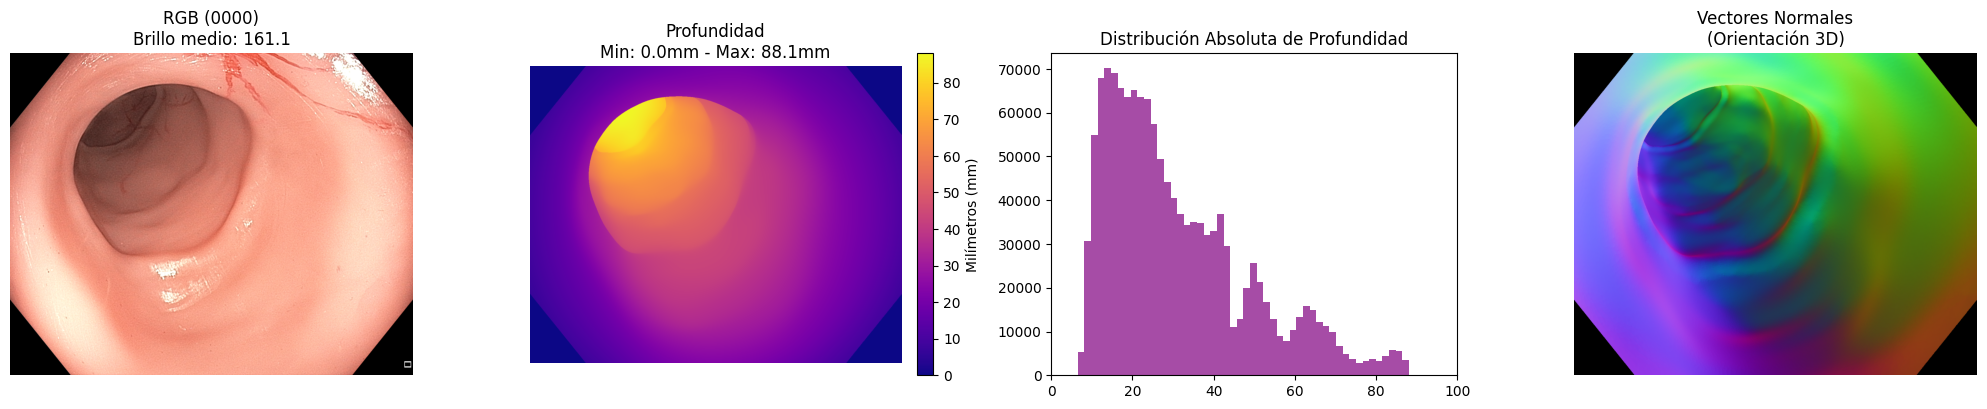


 Procesando frame: 0001
  Modalidades completas. Generando gráficos...


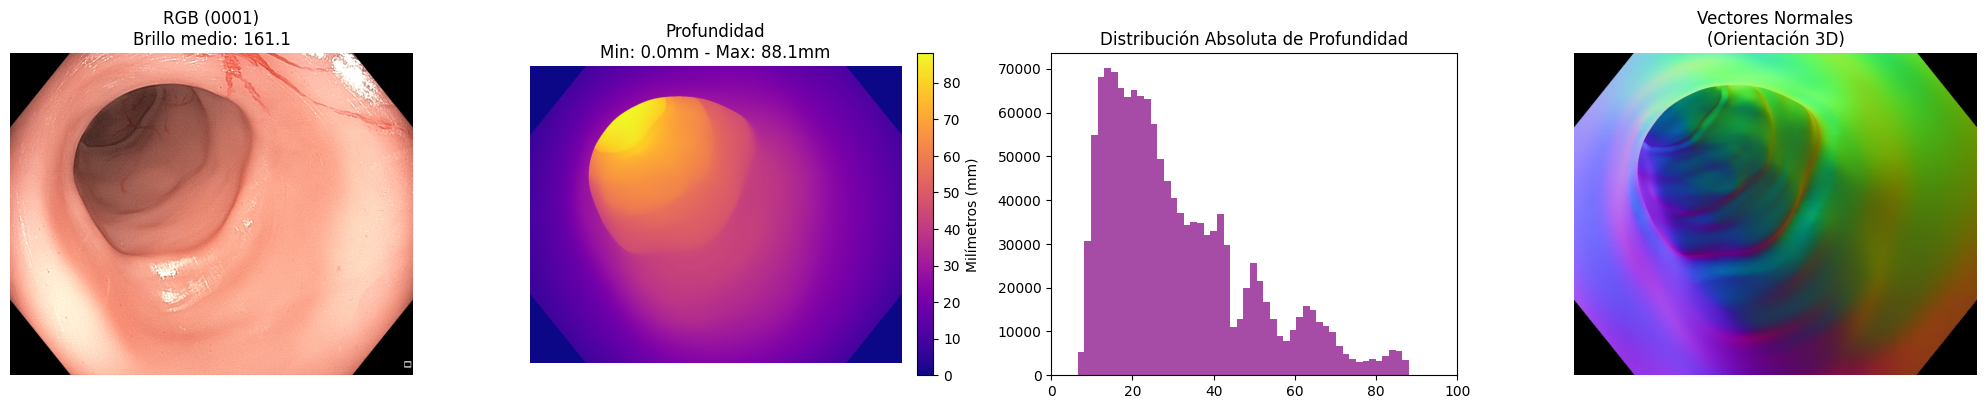


 Procesando frame: 0002
  Modalidades completas. Generando gráficos...


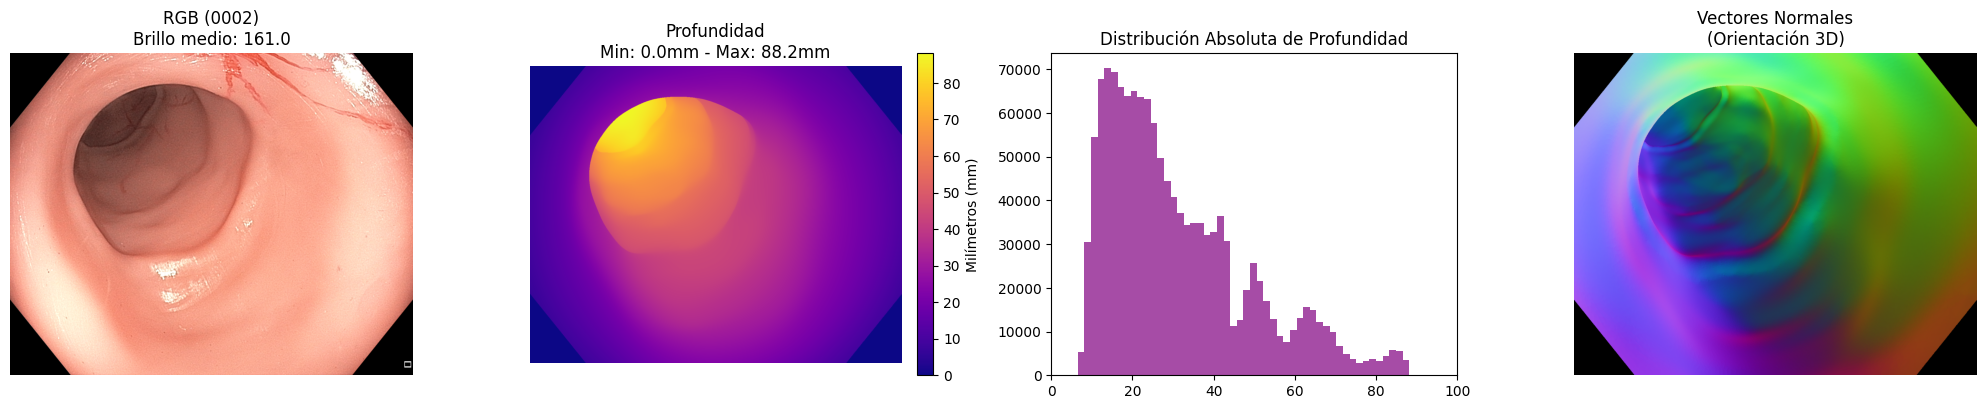


--- SÍNTESIS DE ILUMINACIÓN PARA REPORTE ---
 Desviación Estándar del brillo inter-frame: 0.0
 Conclusión: Iluminación estable. No urge normalización.


In [56]:
import cv2
import glob

# Forzar a Colab a renderizar gráficas
%matplotlib inline

# Ruta donde se extrajeron directamente las carpetas rgb, depth y normals
directorio_base = '/content/drive/MyDrive/Colab Notebooks/EDA_C3VD'

def analizar_etapa5_modalidades_seguro(directorio, num_frames=3):
    print("--- ETAPA 5: ANÁLISIS MULTIMODAL A NIVEL DE PÍXEL ---")

    ruta_rgb = os.path.join(directorio, 'rgb')
    ruta_depth = os.path.join(directorio, 'depth')
    ruta_normals = os.path.join(directorio, 'normals')

    frames_disponibles = sorted(glob.glob(os.path.join(ruta_rgb, "*.png")))
    if not frames_disponibles:
        print("No se encontraron archivos PNG en la carpeta 'rgb'.")
        return

    frames_a_analizar = frames_disponibles[:num_frames]
    brillo_promedio_total = []

    for ruta_img_rgb in frames_a_analizar:
        nombre_base = os.path.basename(ruta_img_rgb).replace('.png', '')
        print(f"\n Procesando frame: {nombre_base}")

        # 1. Carga de RGB Real
        img_rgb = cv2.imread(ruta_img_rgb)
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
        brillo_medio = np.mean(img_rgb)
        brillo_promedio_total.append(brillo_medio)

        # 2. BÚSQUEDA DINÁMICA DE PROFUNDIDAD (Soporta 0001.tiff o 0001_depth.tiff)
        busqueda_depth = glob.glob(os.path.join(ruta_depth, f"*{nombre_base}*.tiff"))
        if not busqueda_depth:
            print(f"  No se encontró el archivo de profundidad para el frame {nombre_base}.")
            continue
        depth_raw = cv2.imread(busqueda_depth[0], cv2.IMREAD_UNCHANGED)

        # 3. BÚSQUEDA DINÁMICA DE NORMALES (Soporta 0001.tiff o 0001_normals.tiff)
        busqueda_normals = glob.glob(os.path.join(ruta_normals, f"*{nombre_base}*.tiff"))
        if not busqueda_normals:
            print(f"  No se encontró el archivo de normales para el frame {nombre_base}.")
            continue
        normals_raw = cv2.imread(busqueda_normals[0], cv2.IMREAD_UNCHANGED)

        print("  Modalidades completas. Generando gráficos...")

        # --- CORRECCIONES FÍSICAS ---
        # Escalar profundidad a Milímetros exactos (0 a 100 mm)
        depth_mm = (depth_raw.astype(np.float32) / 65535.0) * 100.0

        # Estandarizar normales a 8-bit solo para poder renderizarlas en pantalla
        normals_vis = cv2.normalize(normals_raw, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

        # --- VISUALIZACIÓN ---
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))

        axes[0].imshow(img_rgb)
        axes[0].set_title(f"RGB ({nombre_base})\nBrillo medio: {brillo_medio:.1f}")
        axes[0].axis('off')

        im_d = axes[1].imshow(depth_mm, cmap='plasma')
        axes[1].set_title(f"Profundidad\nMin: {depth_mm.min():.1f}mm - Max: {depth_mm.max():.1f}mm")
        axes[1].axis('off')
        fig.colorbar(im_d, ax=axes[1], fraction=0.046, pad=0.04, label="Milímetros (mm)")

        axes[2].hist(depth_mm[depth_mm > 0].flatten(), bins=50, color='purple', alpha=0.7)
        axes[2].set_title("Distribución Absoluta de Profundidad")
        axes[2].set_xlim(0, 100)

        axes[3].imshow(normals_vis)
        axes[3].set_title("Vectores Normales\n(Orientación 3D)")
        axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    # --- RESPUESTA A LA PREGUNTA 9 DEL PIPELINE ---
    if brillo_promedio_total:
        desviacion_brillo = np.std(brillo_promedio_total)
        print("\n--- SÍNTESIS DE ILUMINACIÓN PARA REPORTE ---")
        print(f" Desviación Estándar del brillo inter-frame: {desviacion_brillo:.1f}")
        if desviacion_brillo > 15:
            print(" Conclusión: Alta varianza de iluminación. Se requiere normalización (ej. CLAHE).")
        else:
            print(" Conclusión: Iluminación estable. No urge normalización.")

# Ejecutar
analizar_etapa5_modalidades_seguro(directorio_base, num_frames=3)

## Etapa 6: Sesgo Espacial y Balance de Clases
Esta etapa se enfoca en la distribución de la variable que el modelo debe predecir (Profundidad) y el sesgo geométrico de la cámara. Es crítica para prevenir que las redes neuronales memoricen la forma del colon en lugar de aprender características visuales.

Sesgo Espacial Promedio: Generamos un mapa de profundidad medio para identificar si existe una tendencia central (efecto túnel) intrínseca al dataset.

Distribución de Campo (Field-of-View): Clasificamos los píxeles en rangos de "Cerca", "Medio" y "Lejos" para cuantificar el desbalance de la variable objetivo.

Implicaciones de Modelado: Los resultados de esta etapa justifican la necesidad de funciones de pérdida ponderadas que penalicen con mayor rigor los errores en las distancias menos representadas (campo lejano).


In [ ]:
# Análisis de sesgo espacial por rangos de profundidad absoluta
# Etapa 6: distribución Near / Mid / Far sin sesgo de fisheye

def analizar_sesgo_espacial(directorio, num_frames=10):
    ruta_depth = os.path.join(directorio, 'depth')
    frames_depth = sorted(glob.glob(os.path.join(ruta_depth, "*.tiff")))

    if not frames_depth:
        print(f"No se encontraron archivos .tiff en: {ruta_depth}")
        return

    print(f"Archivos encontrados: {len(frames_depth)}. Analizando muestra de {num_frames}...")
    frames_a_analizar = frames_depth[:num_frames]

    total_near = total_mid = total_far = total_valid = 0

    for i, ruta in enumerate(frames_a_analizar):
        depth_raw = cv2.imread(ruta, cv2.IMREAD_UNCHANGED)
        if depth_raw is None:
            print(f"  [{i+1}] No se pudo leer: {os.path.basename(ruta)}")
            continue

        # Convertir a milímetros (rango original: uint16 → 0–100 mm)
        depth_mm = (depth_raw.astype(np.float32) / 65535.0) * 100.0
        validos = depth_mm[depth_mm > 0.1]

        if len(validos) == 0:
            print(f"  [{i+1}] Sin píxeles válidos: {os.path.basename(ruta)}")
            continue

        total_near  += np.sum(validos <= 20)
        total_mid   += np.sum((validos > 20) & (validos <= 50))
        total_far   += np.sum(validos > 50)
        total_valid += len(validos)
        print(f"  [{i+1}] {len(validos):,} píxeles válidos — {os.path.basename(ruta)}")

    if total_valid == 0:
        print("Ningún frame válido. No se puede generar la gráfica.")
        return

    pct_near = total_near / total_valid * 100
    pct_mid  = total_mid  / total_valid * 100
    pct_far  = total_far  / total_valid * 100

    etiquetas   = ['Near (0–20 mm)', 'Mid (20–50 mm)', 'Far (50–100 mm)']
    porcentajes = [pct_near, pct_mid, pct_far]
    colores     = ['#ff9999', '#66b3ff', '#99ff99']

    plt.figure(figsize=(7, 6))
    plt.pie(porcentajes, labels=etiquetas, autopct='%1.1f%%',
            colors=colores, startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title(f"Distribución de profundidad absoluta\n(muestra: {num_frames} frames, sin sesgo fisheye)")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    print(f"\nNear  (0–20 mm):  {pct_near:.1f}%")
    print(f"Mid   (20–50 mm): {pct_mid:.1f}%")
    print(f"Far   (50–100 mm):{pct_far:.1f}%")
    if pct_far < 20:
        print("\nNota: la clase Far es minoritaria. Considerar una función de pérdida")
        print("balanceada espacialmente (Spatially Weighted Loss) para evitar sobreajuste")
        print("hacia las distancias cortas.")

analizar_sesgo_espacial(directorio_base, num_frames=10)


---

## Agradecimientos

El Equipo 52 agradece la orientacion y asesoria tecnica del **Dr. Gilberto Ochoa Ruiz** y del **Dr. Ricardo Espinosa Loera** (Universite de Lorraine), cuyas contribuciones al campo de la vision por computadora y el procesamiento de imagenes medicas enriquecieron el diseno metodologico de este proyecto.
